In [ ]:
"""
Adversarial Robustness Study — CIFAR-10
========================================
Project: Adversarial Attacks & Defense on Image Classifiers
Stack:   PyTorch, Torchvision
Attacks: FGSM, PGD (white-box)
Defense: Adversarial Training

Install dependencies:
    pip install torch torchvision matplotlib numpy
"""

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE  = 128
NUM_EPOCHS  = 15         # increase for better baseline (10–20 recommended)
ADV_EPOCHS  = 10         # epochs for adversarial training
EPS         = 8 / 255    # perturbation budget (L-inf norm, standard in papers)
PGD_STEPS   = 10         # PGD attack steps
PGD_ALPHA   = 2 / 255    # PGD step size

print(f"Using device: {DEVICE}")

Using device: cuda


In [ ]:
# ─────────────────────────────────────────────
# 1. DATA LOADING
# ─────────────────────────────────────────────
def get_cifar10_loaders():
    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        # NOTE: No normalization — keeps pixel values in [0,1] which
        # simplifies adversarial perturbation clamping.
    ])
    transform_test = transforms.Compose([transforms.ToTensor()])

    trainset = torchvision.datasets.CIFAR10(
        root="./data", train=True, download=True, transform=transform_train)
    testset  = torchvision.datasets.CIFAR10(
        root="./data", train=False, download=True, transform=transform_test)

    train_loader = torch.utils.data.DataLoader(
        trainset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
    test_loader  = torch.utils.data.DataLoader(
        testset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    return train_loader, test_loader

In [ ]:
# ─────────────────────────────────────────────
# 2. MODEL
# ─────────────────────────────────────────────
def get_model():
    """ResNet-18 adapted for CIFAR-10 (32x32 input)."""
    model = models.resnet18(weights=None)
    # CIFAR images are 32x32, not 224x224 — shrink the first conv layer
    model.conv1  = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc     = nn.Linear(512, 10)
    return model.to(DEVICE)

In [ ]:
# ─────────────────────────────────────────────
# 3. ATTACKS
# ─────────────────────────────────────────────
def fgsm_attack(model, images, labels, eps=EPS):
    """
    Fast Gradient Sign Method (Goodfellow et al., 2014).
    Single-step attack: x_adv = x + eps * sign(∇_x L(x, y))
    """
    images.requires_grad = True
    outputs = model(images)
    loss    = nn.CrossEntropyLoss()(outputs, labels)
    model.zero_grad()
    loss.backward()

    perturbation = eps * images.grad.sign()
    adv_images   = torch.clamp(images + perturbation, 0, 1).detach()
    return adv_images


def pgd_attack(model, images, labels, eps=EPS, alpha=PGD_ALPHA, steps=PGD_STEPS):
    """
    Projected Gradient Descent (Madry et al., 2018).
    Multi-step FGSM with projection back into the eps-ball.
    Considered the standard strong white-box attack.
    """
    adv_images = images.clone().detach()
    # Start from a random point inside the eps-ball
    adv_images = adv_images + torch.empty_like(adv_images).uniform_(-eps, eps)
    adv_images = torch.clamp(adv_images, 0, 1).detach()

    for _ in range(steps):
        adv_images.requires_grad = True
        outputs = model(adv_images)
        loss    = nn.CrossEntropyLoss()(outputs, labels)
        model.zero_grad()
        loss.backward()

        # Gradient step + project back into [x-eps, x+eps] ∩ [0,1]
        adv_images = adv_images + alpha * adv_images.grad.sign()
        delta      = torch.clamp(adv_images - images, -eps, eps)
        adv_images = torch.clamp(images + delta, 0, 1).detach()

    return adv_images

In [ ]:
# ─────────────────────────────────────────────
# 4. TRAINING
# ─────────────────────────────────────────────
def train_standard(model, loader, epochs=NUM_EPOCHS):
    """Standard (clean) training."""
    optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()

    model.train()
    for epoch in range(epochs):
        total_loss, correct, total = 0, 0, 0
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total   += labels.size(0)

        scheduler.step()
        print(f"[Standard] Epoch {epoch+1}/{epochs} | "
              f"Loss: {total_loss/len(loader):.3f} | "
              f"Acc: {100.*correct/total:.2f}%")


def train_adversarial(model, loader, epochs=ADV_EPOCHS):
    """
    Adversarial Training (Madry et al., 2018).
    At each step: generate PGD adversarial examples, train on them.
    This is the de-facto standard defense in the literature.
    """
    optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
    criterion = nn.CrossEntropyLoss()

    model.train()
    for epoch in range(epochs):
        total_loss, correct, total = 0, 0, 0
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            # Generate adversarial examples on-the-fly
            adv_images = pgd_attack(model, images, labels)

            optimizer.zero_grad()
            outputs = model(adv_images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total   += labels.size(0)

        print(f"[Adversarial] Epoch {epoch+1}/{epochs} | "
              f"Loss: {total_loss/len(loader):.3f} | "
              f"Adv Train Acc: {100.*correct/total:.2f}%")

In [ ]:
# ─────────────────────────────────────────────
# 5. EVALUATION
# ─────────────────────────────────────────────
def evaluate(model, loader, attack_fn=None, attack_name="Clean"):
    """Evaluate model accuracy on clean or adversarial examples."""
    model.eval()
    correct, total = 0, 0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        if attack_fn is not None:
            images = attack_fn(model, images, labels)
        with torch.no_grad():
            outputs = model(images)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total   += labels.size(0)

    acc = 100. * correct / total
    print(f"  [{attack_name}] Accuracy: {acc:.2f}%")
    return acc

In [ ]:
# ─────────────────────────────────────────────
# 6. VISUALIZATION
# ─────────────────────────────────────────────
def visualize_adversarial_examples(model, loader, n=5):
    """Show original vs adversarial images side by side."""
    model.eval()
    images, labels = next(iter(loader))
    images, labels = images[:n].to(DEVICE), labels[:n].to(DEVICE)

    fgsm_imgs = fgsm_attack(model, images.clone(), labels)
    pgd_imgs  = pgd_attack(model,  images.clone(), labels)

    classes = ['plane','car','bird','cat','deer',
               'dog','frog','horse','ship','truck']

    fig, axes = plt.subplots(3, n, figsize=(2.5*n, 7))
    fig.suptitle("Adversarial Examples (top: clean | mid: FGSM | bot: PGD)", fontsize=12)

    for i in range(n):
        for row, (img, title) in enumerate([
            (images[i],    f"Clean\n{classes[labels[i]]}"),
            (fgsm_imgs[i], "FGSM"),
            (pgd_imgs[i],  "PGD"),
        ]):
            axes[row, i].imshow(img.cpu().permute(1, 2, 0).numpy())
            if i == 0:
                axes[row, i].set_ylabel(title.split('\n')[0], fontsize=9)
            axes[row, i].axis("off")

    plt.tight_layout()
    plt.savefig("adversarial_examples.png", dpi=150)
    plt.show()
    print("Saved: adversarial_examples.png")


def plot_results(results: dict):
    """Bar chart comparing clean vs adversarial accuracy."""
    labels  = list(results.keys())
    values  = list(results.values())
    colors  = ["#4CAF50" if "Clean" in l else "#F44336" if "PGD" in l else "#FF9800"
               for l in labels]

    plt.figure(figsize=(8, 5))
    bars = plt.bar(labels, values, color=colors, edgecolor="black", width=0.5)
    for bar, val in zip(bars, values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f"{val:.1f}%", ha="center", fontsize=10)
    plt.ylim(0, 105)
    plt.ylabel("Accuracy (%)")
    plt.title("Standard vs. Adversarially Trained Model — Robustness Comparison")
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout()
    plt.savefig("robustness_comparison.png", dpi=150)
    plt.show()
    print("Saved: robustness_comparison.png")


=== Phase 1: Standard Training ===
[Standard] Epoch 1/15 | Loss: 1.905 | Acc: 31.47%
[Standard] Epoch 2/15 | Loss: 1.361 | Acc: 50.11%
[Standard] Epoch 3/15 | Loss: 1.077 | Acc: 61.38%
[Standard] Epoch 4/15 | Loss: 0.892 | Acc: 68.43%
[Standard] Epoch 5/15 | Loss: 0.727 | Acc: 74.45%
[Standard] Epoch 6/15 | Loss: 0.616 | Acc: 78.64%
[Standard] Epoch 7/15 | Loss: 0.536 | Acc: 81.31%
[Standard] Epoch 8/15 | Loss: 0.467 | Acc: 83.90%
[Standard] Epoch 9/15 | Loss: 0.410 | Acc: 85.91%
[Standard] Epoch 10/15 | Loss: 0.357 | Acc: 87.68%
[Standard] Epoch 11/15 | Loss: 0.300 | Acc: 89.61%
[Standard] Epoch 12/15 | Loss: 0.245 | Acc: 91.48%
[Standard] Epoch 13/15 | Loss: 0.199 | Acc: 93.27%
[Standard] Epoch 14/15 | Loss: 0.162 | Acc: 94.59%
[Standard] Epoch 15/15 | Loss: 0.140 | Acc: 95.45%

=== Evaluating Standard Model ===
  [Clean] Accuracy: 91.13%
  [FGSM] Accuracy: 5.73%
  [PGD] Accuracy: 0.00%

=== Phase 2: Adversarial Training ===
[Adversarial] Epoch 1/10 | Loss: 2.230 | Adv Train Acc: 25

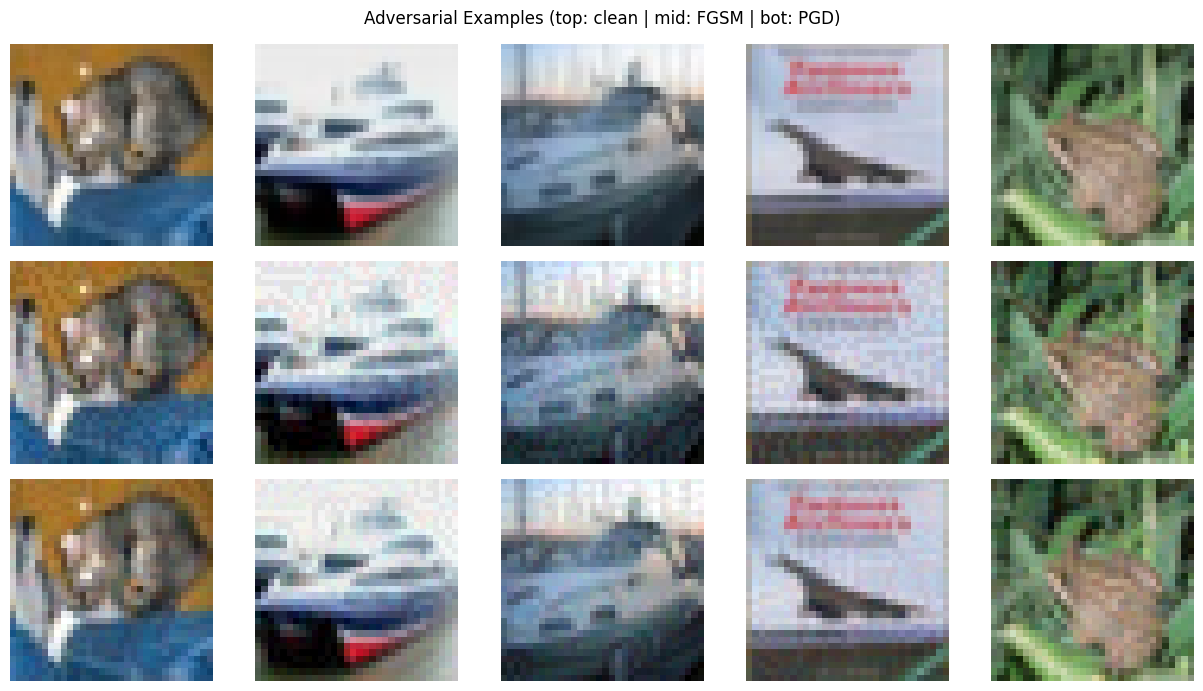

Saved: adversarial_examples.png


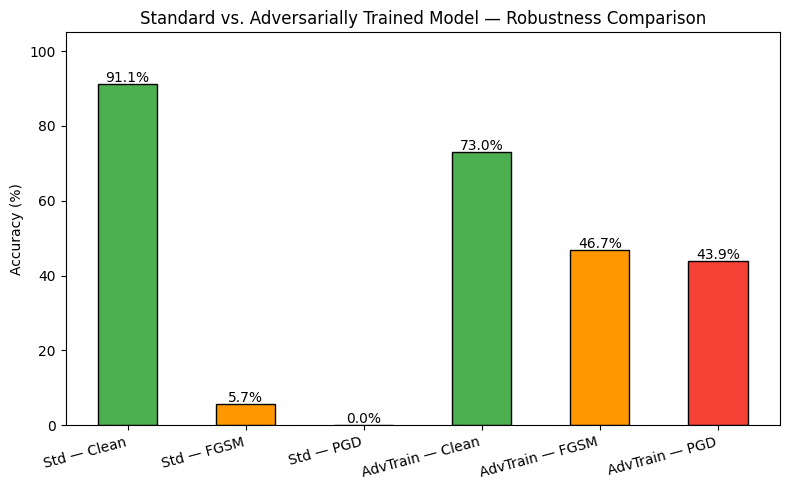

Saved: robustness_comparison.png

=== Summary ===
Standard model  | Clean: 91.1% | FGSM: 5.7% | PGD: 0.0%
Adv-trained     | Clean: 73.0% | FGSM: 46.7% | PGD: 43.9%

Key insight: adversarial training trades some clean accuracy for significantly better robustness under attack.


In [ ]:
# ─────────────────────────────────────────────
# 7. MAIN
# ─────────────────────────────────────────────
if __name__ == "__main__":
    train_loader, test_loader = get_cifar10_loaders()

    # ── Phase 1: Standard model ──────────────────
    print("\n=== Phase 1: Standard Training ===")
    std_model = get_model()
    train_standard(std_model, train_loader)

    print("\n=== Evaluating Standard Model ===")
    r1 = evaluate(std_model, test_loader, attack_fn=None,        attack_name="Clean")
    r2 = evaluate(std_model, test_loader, attack_fn=fgsm_attack, attack_name="FGSM")
    r3 = evaluate(std_model, test_loader, attack_fn=pgd_attack,  attack_name="PGD")

    # ── Phase 2: Adversarially trained model ─────
    print("\n=== Phase 2: Adversarial Training ===")
    adv_model = get_model()
    # Optional: load standard weights as starting point for faster convergence
    adv_model.load_state_dict(std_model.state_dict())
    train_adversarial(adv_model, train_loader)

    print("\n=== Evaluating Adversarially Trained Model ===")
    r4 = evaluate(adv_model, test_loader, attack_fn=None,        attack_name="Clean")
    r5 = evaluate(adv_model, test_loader, attack_fn=fgsm_attack, attack_name="FGSM")
    r6 = evaluate(adv_model, test_loader, attack_fn=pgd_attack,  attack_name="PGD")

    # ── Phase 3: Visualize ────────────────────────
    print("\n=== Generating Visualizations ===")
    visualize_adversarial_examples(std_model, test_loader)

    results = {
        "Std — Clean":     r1,
        "Std — FGSM":      r2,
        "Std — PGD":       r3,
        "AdvTrain — Clean": r4,
        "AdvTrain — FGSM": r5,
        "AdvTrain — PGD":  r6,
    }
    plot_results(results)

    print("\n=== Summary ===")
    print(f"Standard model  | Clean: {r1:.1f}% | FGSM: {r2:.1f}% | PGD: {r3:.1f}%")
    print(f"Adv-trained     | Clean: {r4:.1f}% | FGSM: {r5:.1f}% | PGD: {r6:.1f}%")
    print("\nKey insight: adversarial training trades some clean accuracy "
          "for significantly better robustness under attack.")